### Inferring parameters for the dependence of $N_{steps}^{limit}$ on several parameters

The form that seems to work is 

$$
N_{steps}^{limit} = N_{combined} \times cr^{m_{c_r}} \times \omega_{\nu}^{m_{\omega}}
$$

In [36]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams
import time
from copy import copy as dup
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from pint import UnitRegistry; AssignQuantity = UnitRegistry().Quantity
from importlib import reload
from matplotlib.gridspec import GridSpec

# My modules
import sys; sys.path.append('..')
import importlib  # Import the importlib module
import QLCstuff as QLC
import f90nml

In [37]:
# Graphics parameters
%matplotlib inline
ticklabelsize = 11
fontsize = 15
linewidth = 2

In [38]:
# Get default parameters
GIfile = '../GI parameters - Table 1.nml'
sigmaI_corner_ref, sigma0_ref, cr_ref, sigmaI_QLC_ref, Nbar_ref, Nstar_ref, h_layer_ref, D_ref, nu_kin_ref, L_ref, nx_crystal_ref, t_eq_ref, x_QLC_ref, DoverL2pi2_ref, Doverdeltax2_ref = \
    QLC.get_system_parameters(GIfile, AssignQuantity)
print('\nConverting to dimensionless ...')
cr_ref.ito('dimensionless'); print(cr_ref)
sigma0_ref.ito('dimensionless'); print(sigma0_ref)
sigmaI_QLC_ref.ito('dimensionless'); print(sigmaI_QLC_ref[0])
odemethod_ref, tkeep_1Darr_ref, Ntot_init_1D_ref, NQLL_init_1D_ref = \
    QLC.get_runtime_parameters(GIfile, nx_crystal_ref, Nstar_ref, Nbar_ref, AssignQuantity)


Using parameter file ../GI parameters - Table 1.nml ...
sigmaI_corner = 22 percent
sigma0 = 20 percent
c_r = 0.2 percent
Nbar 1
Nstar 0.1
h_layer = 0.37 nanometer
D = 0.0002 micrometer ** 2 / microsecond
nu_kin = 0.264 / microsecond
L = 50 micrometer
nx (crystal) = 501
t_eq = 1.5 microsecond
Spacing of points on the ice surface = 0.20000000000000284 micrometer
omega_kin = 0.396 dimensionless

Converting to dimensionless ...
0.002 dimensionless
0.2 dimensionless
0.22 dimensionless

Using parameter file ../GI parameters - Table 1.nml ...
runtime = 300 millisecond
odemethod = RK45
This is a run from time 0.0 millisecond to 300.0 millisecond
dt = 6122.448979591837 microsecond


In [50]:
# Loading 
crfile = 'Nsteps_limit(c_r).txt'
cr_range, Nsteps_cr_range = np.loadtxt(crfile)
print('cr_range',cr_range)
print('Nsteps_cr_range',Nsteps_cr_range)

omega_file = 'Nsteps_limit(omega_kin).txt'
omega_range, Nsteps_omega_range = np.loadtxt(omega_file)
print('omega_range',omega_range); print('shape',np.shape(omega_range))
print('Nsteps_omega_range',Nsteps_omega_range); print('shape',np.shape(Nsteps_omega_range))

Dfile = 'Nsteps_limit(D).txt'
D_range, Nsteps_D_range = np.loadtxt(Dfile)
print('D_range',D_range)
print('Nsteps_D_range',Nsteps_D_range)

cr_range [0.05       0.06888889 0.08777778 0.10666667 0.12555556 0.14444444
 0.16333333 0.18222222 0.20111111 0.22      ]
Nsteps_cr_range [10.02339304 11.97239721 13.40632429 14.96487948 16.05506617 17.14234431
 18.22605557 19.25405162 20.22291052 21.18890781]
omega_range [0.099  0.1364 0.1738 0.2112 0.2486 0.286  0.3234 0.3608 0.3982 0.4356]
shape (10,)
Nsteps_omega_range [ 9.05748578 10.98020766 12.35550277 14.01744898 15.56079086 16.46965669
 18.08587277 19.4983042  20.22011489 21.91346735]
shape (10,)
D_range [0.00012    0.00013818 0.00015636 0.00017455 0.00019273 0.00021091
 0.00022909 0.00024727 0.00026545 0.00028364 0.00030182 0.00032   ]
Nsteps_D_range [26.73841502 24.80256107 23.40571169 21.9254959  20.88618438 19.94092031
 19.32646766 18.72288379 17.8424495  17.5102853  16.80419677 16.49620561]


From fit ...  [0.49842651 6.10399567]
m = 0.4984265071646885
using m_cr 0.4984
Nsteps_cr_factor = 447.64283551914144


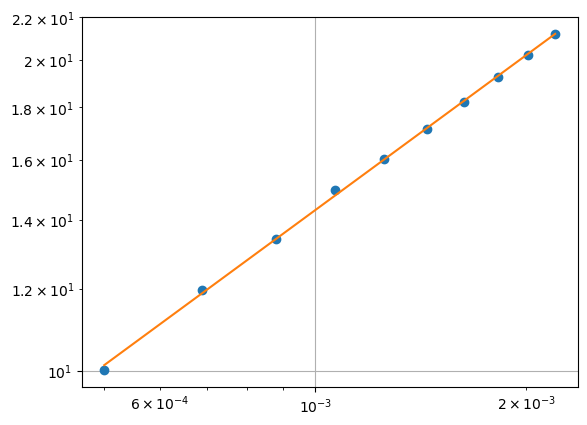

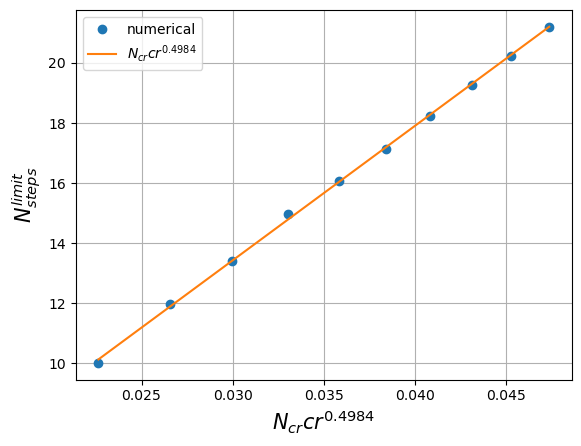

In [52]:
# Working on Nsteps as a function of cr

# Plot as a log-log, and fit
plt.figure()
cr_range /= 100 # Assumes it was saved as a %
plt.loglog(cr_range,Nsteps_cr_range,'o')
x = np.log(cr_range)
y = np.log(Nsteps_cr_range)
p = np.polyfit(x,y,1); print('From fit ... ', p)
m = p[0]; b = p[1]
logcr = np.polyval(p,x)
cr_fit = np.exp(logcr)
plt.loglog(cr_range,cr_fit)
plt.grid(True)

plt.figure()
print('m =',m)
m_cr = np.round(m,4); print('using m_cr',m_cr)
m_cr_label = '$N_{cr} cr^{'+str(m_cr)+'}$'
Nsteps_cr_factor = np.exp(b); print('Nsteps_cr_factor =',Nsteps_cr_factor)
Nsteps_cr_range_fit = Nsteps_cr_factor*cr_range**m_cr
plt.plot(cr_range**m_cr,Nsteps_cr_range,'o',label='numerical')
plt.plot(cr_range**m_cr,Nsteps_cr_range_fit,label=m_cr_label)
plt.xlabel(m_cr_label,fontsize=fontsize)
plt.ylabel('$N_{steps}^{limit}$',fontsize=fontsize)
plt.legend()
plt.grid(True)

figfilename = 'Nsteps_limit(cr).png'
plt.savefig(figfilename,dpi=200)

omega_range [0.099  0.1364 0.1738 0.2112 0.2486 0.286  0.3234 0.3608 0.3982 0.4356]
shape (10,)
Nsteps_omega_range [ 9.05748578 10.98020766 12.35550277 14.01744898 15.56079086 16.46965669
 18.08587277 19.4983042  20.22011489 21.91346735]
shape (10,)
[0.58909264 3.55972666]
m = 0.5890926403279386
using m_omega 0.5891
Nsteps_omega_factor = 35.15358708691115


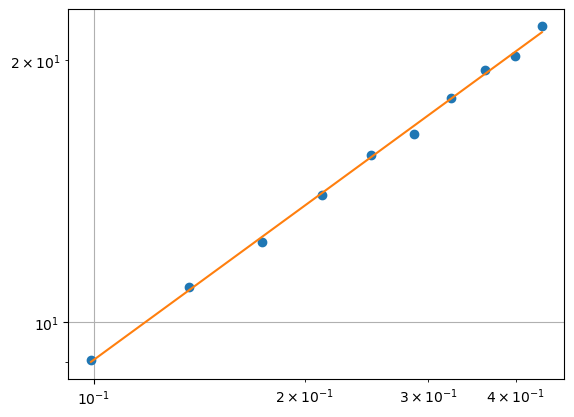

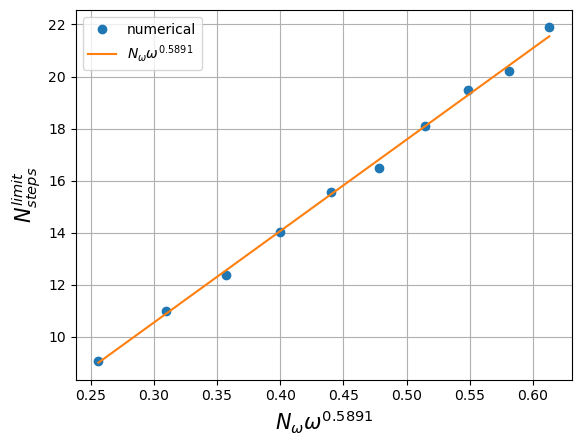

In [54]:
# Working on Nsteps as a function of omega

print('omega_range',omega_range); print('shape',np.shape(omega_range))
print('Nsteps_omega_range',Nsteps_omega_range); print('shape',np.shape(Nsteps_omega_range))


# Plot as a log-log
plt.figure()
plt.loglog(omega_range,Nsteps_omega_range,'o')
x = np.log(omega_range)
y = np.log(Nsteps_omega_range)
p = np.polyfit(x,y,1); print(p)
m = p[0]; b = p[1]
logNsteps = np.polyval(p,x)
Nsteps_fit = np.exp(logNsteps)
plt.loglog(omega_range,Nsteps_fit)
plt.grid(True)

plt.figure()
print('m =',m)
m_omega = np.round(m,4); print('using m_omega',m_omega)
m_omega_label = '$N_{\omega} \omega^{'+str(m_omega)+'}$'
Nsteps_omega_factor = np.exp(b); print('Nsteps_omega_factor =',Nsteps_omega_factor)
Nsteps_omega_range_fit = Nsteps_omega_factor*omega_range**m_omega
plt.plot(omega_range**m_omega,Nsteps_omega_range,'o',label='numerical')
plt.plot(omega_range**m_omega,Nsteps_omega_range_fit,label=m_omega_label)
plt.xlabel(m_omega_label,fontsize=fontsize)
plt.ylabel('$N_{steps}^{limit}$',fontsize=fontsize)
plt.legend()
plt.grid(True)

figfilename = 'Nsteps_limit(omega).png'
plt.savefig(figfilename,dpi=200,bbox_inches="tight")

From fit ...  [-0.49272226 -1.16885883]
m = -0.49272226426396454
using m_D -0.4927
Nsteps_D_factor = 0.31072132620604825


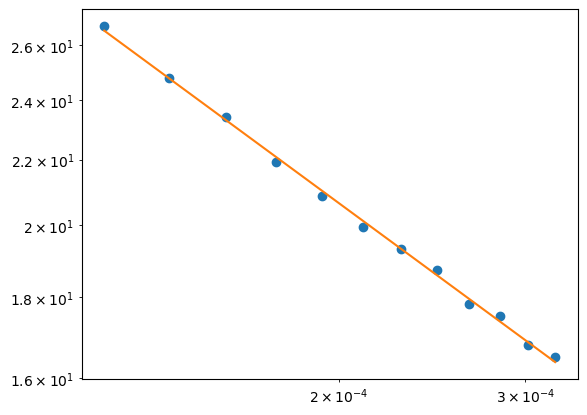

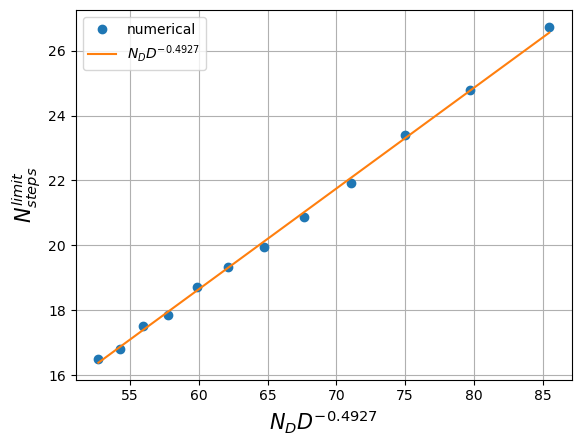

In [58]:
# Working on Nsteps as a function of D

# Plot as a log-log, and fit
plt.figure()
plt.loglog(D_range,Nsteps_D_range,'o')
x = np.log(D_range)
y = np.log(Nsteps_D_range)
p = np.polyfit(x,y,1); print('From fit ... ', p)
m = p[0]; b = p[1]
logD = np.polyval(p,x)
D_fit = np.exp(logD)
plt.loglog(D_range,D_fit)
plt.grid(True)

plt.figure()
print('m =',m)
m_D = np.round(m,4); print('using m_D',m_D)
m_D_label = '$N_{D} D^{'+str(m_D)+'}$'
Nsteps_D_factor = np.exp(b); print('Nsteps_D_factor =',Nsteps_D_factor)
Nsteps_D_range_fit = Nsteps_D_factor*D_range**m_D
plt.plot(D_range**m_D,Nsteps_D_range,'o',label='numerical')
plt.plot(D_range**m_D,Nsteps_D_range_fit,label=m_D_label)
plt.xlabel(m_D_label,fontsize=fontsize)
plt.ylabel('$N_{steps}^{limit}$',fontsize=fontsize)
plt.legend()
plt.grid(True)

figfilename = 'Nsteps_limit(D).png'
plt.savefig(figfilename,dpi=200)

cr_ref 0.002 dimensionless
omega_ref 0.396 dimensionless
Nsteps_combined_factor_1 786.0581037929214 dimensionless
Nsteps_combined_factor_2 772.5549935519145 dimensionless
N_combined 779.306548672418 dimensionless
approximating N_combined as 779.0 dimensionless


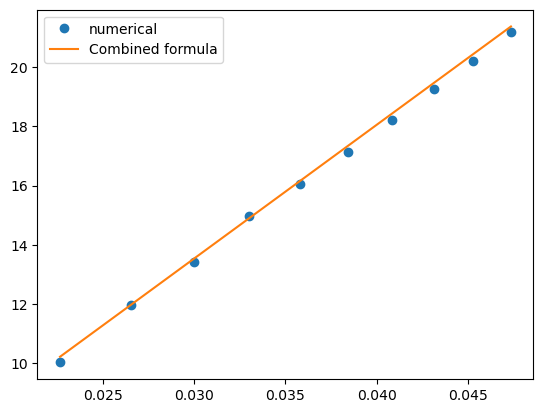

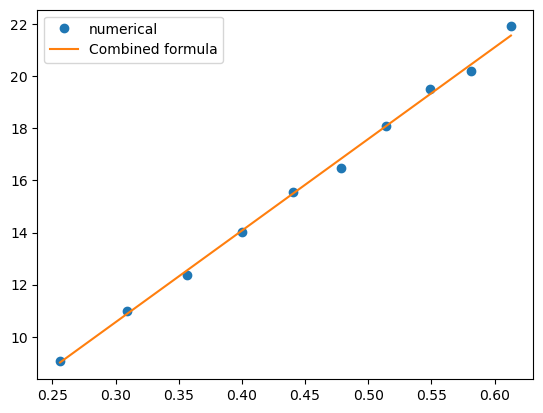

In [19]:
# Putting those forms together
print('cr_ref', cr_ref)
omega_ref = nu_kin_ref*t_eq_ref; print('omega_ref', omega_ref)
print('D_ref',D_ref)

# This will change as we add more to the combined formula (pick up here next)
Nsteps_combined_factor_1 = Nsteps_omega_factor/cr_ref**(1/2); print('Nsteps_combined_factor_1', Nsteps_combined_factor_1)
Nsteps_combined_factor_2 = Nsteps_cr_factor/omega_ref**(m_omega); print('Nsteps_combined_factor_2',Nsteps_combined_factor_2)
Nsteps_combined_factor = (Nsteps_combined_factor_1+Nsteps_combined_factor_2)/2; print('N_combined',Nsteps_combined_factor)
Nsteps_combined_factor = np.round(Nsteps_combined_factor,0)
print('approximating N_combined as', Nsteps_combined_factor)

# Let's test this
plt.figure()
plt.plot(cr_range**m_cr,Nsteps_cr_range,'o',label='numerical')
Nsteps_combined_test_1 = Nsteps_combined_factor*cr_range**m_cr*omega_ref**m_omega
plt.plot(cr_range**m_cr,Nsteps_combined_test_1,label='Combined formula')
plt.legend()

plt.figure()
plt.plot(omega_range**m_omega,Nsteps_omega_range,'o',label='numerical')
Nsteps_combined_test_2 = Nsteps_combined_factor*cr_ref**m_cr*omega_range**m_omega
plt.plot(omega_range**m_omega,Nsteps_combined_test_2,label='Combined formula')
plt.legend()